In [1]:
# ============================================================
# PHASE 3: EXPLORATORY DATA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean, professional style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load the cleaned data from Phase 2
df = pd.read_csv('../data/processed/telco_cleaned_v1.csv')

# Encode target as 0/1 for correlation analysis later
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print("Data loaded. Shape:", df.shape)

Data loaded. Shape: (7043, 22)


In [14]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
# churn = 1(YES) → customer left
# churn = 0(NO) → customer stayed

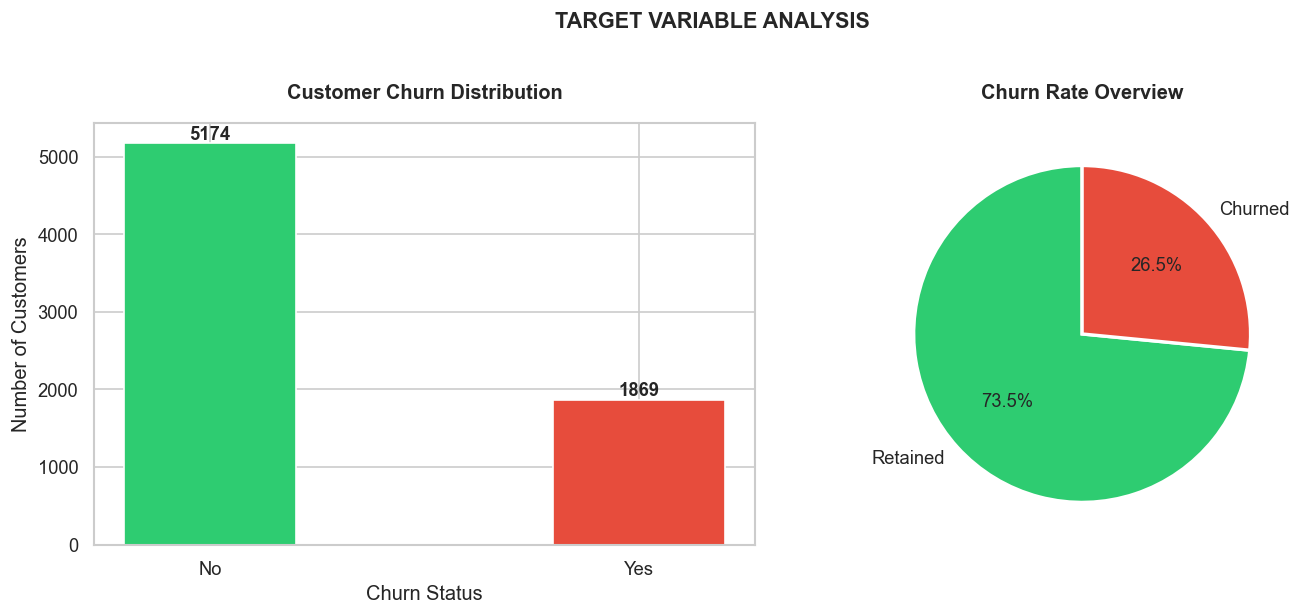


Business Insight: 1869 customers churned (26.5%)
At avg ₹65/month, this is ₹121,485 monthly revenue lost.


In [16]:
# ============================================================
# CHART 1: Target Variable Distribution
# Business question: How severe is the churn problem?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(churn_counts.index, churn_counts.values, color=colors, width=0.4, edgecolor='white')
axes[0].set_title('Customer Churn Distribution', fontweight='bold', pad=15)
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate Overview', fontweight='bold', pad=15)

plt.suptitle('TARGET VARIABLE ANALYSIS', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nBusiness Insight: {churn_counts['Yes']} customers churned ({churn_counts['Yes']/len(df)*100:.1f}%)")
print(f"At avg ₹65/month, this is ₹{churn_counts['Yes'] * 65:,} monthly revenue lost.")

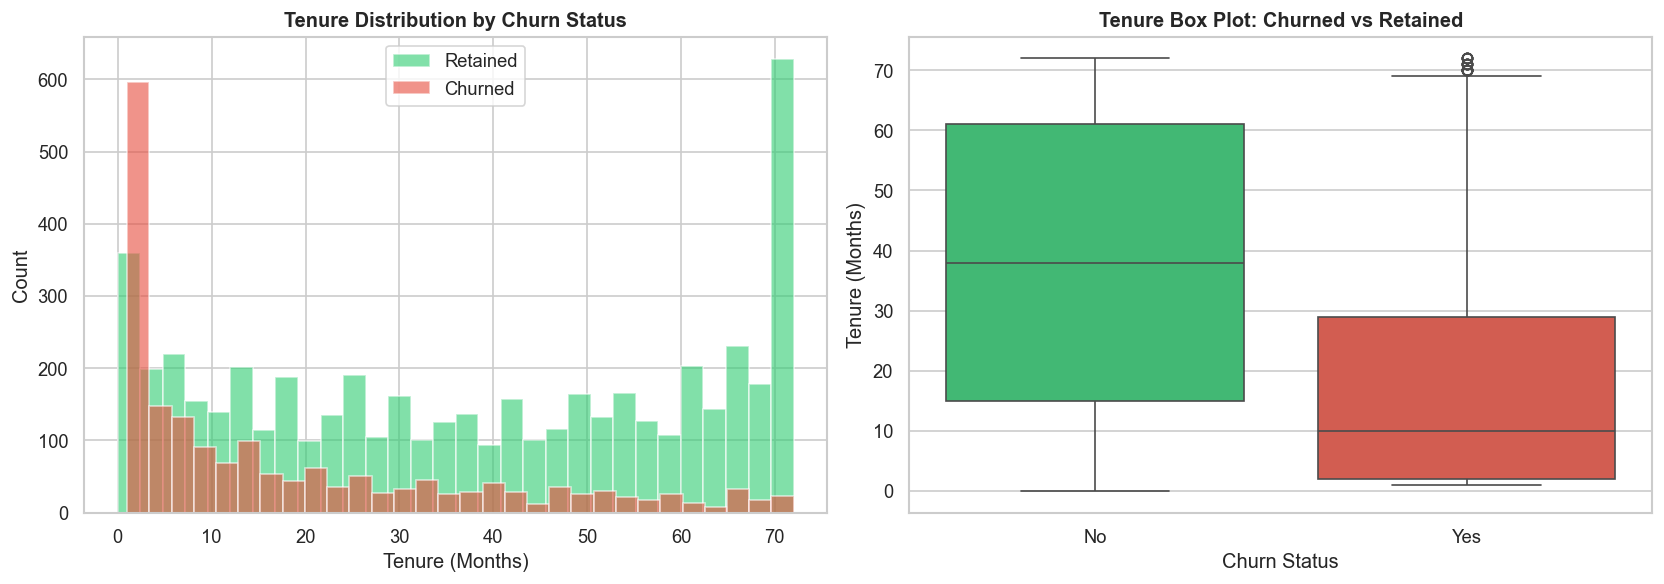

Avg tenure - Retained: 37.6 months
Avg tenure - Churned : 18.0 months

Insight: Churned customers leave much earlier — high risk in first 12 months.


In [3]:
# ============================================================
# CHART 2: Tenure Analysis
# Business question: When do customers most commonly churn?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by churn status
for churn_val, color, label in [('No', '#2ecc71', 'Retained'), ('Yes', '#e74c3c', 'Churned')]:
    subset = df[df['Churn'] == churn_val]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
df_plot = df[['tenure', 'Churn']].copy()
sns.boxplot(data=df_plot, x='Churn', y='tenure',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Tenure Box Plot: Churned vs Retained', fontweight='bold')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Tenure (Months)')

plt.tight_layout()
plt.savefig('../reports/figures/02_tenure_analysis.png', bbox_inches='tight')
plt.show()

# Key insight
print("Avg tenure - Retained:", df[df['Churn']=='No']['tenure'].mean().round(1), "months")
print("Avg tenure - Churned :", df[df['Churn']=='Yes']['tenure'].mean().round(1), "months")
print("\nInsight: Churned customers leave much earlier — high risk in first 12 months.")

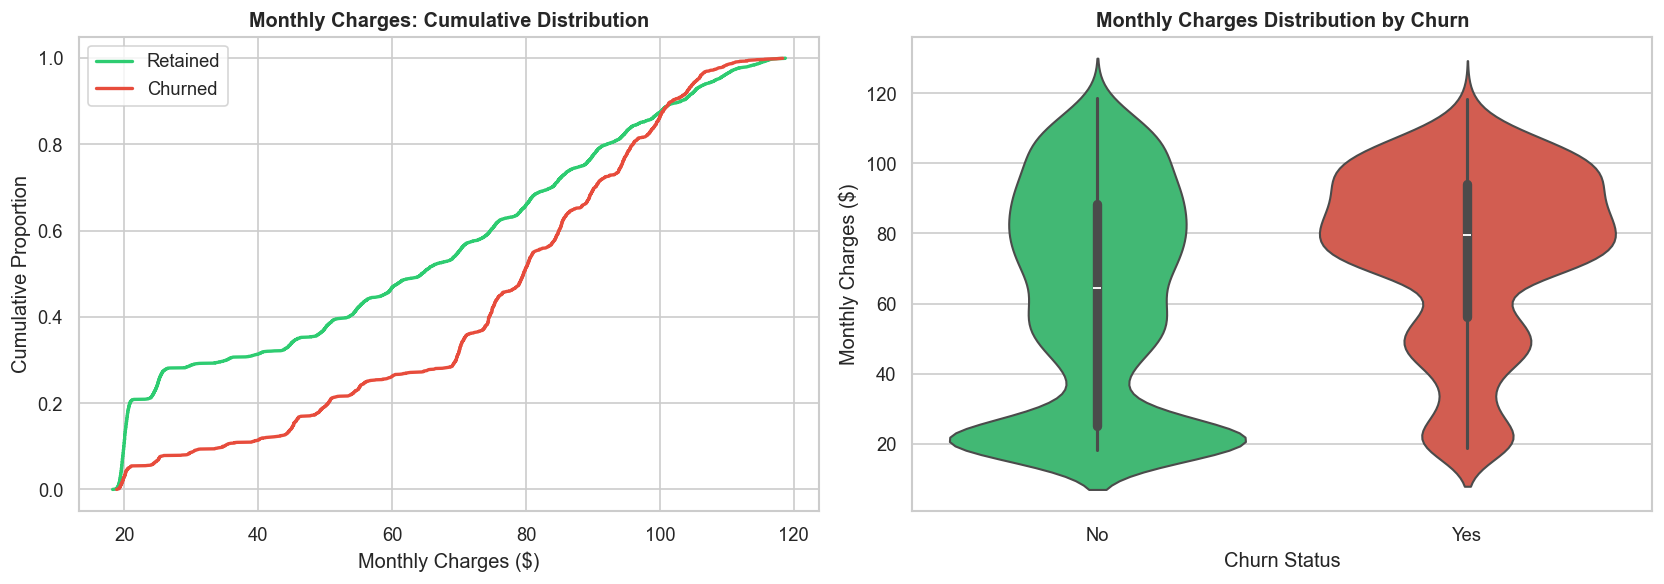

Avg monthly charge - Retained: 61.27
Avg monthly charge - Churned : 74.44


In [4]:
# ============================================================
# CHART 3: Monthly Charges vs Churn
# Business question: Are expensive plans driving churn?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
for churn_val, color, label in [('No', '#2ecc71', 'Retained'), ('Yes', '#e74c3c', 'Churned')]:
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    axes[0].plot(sorted(subset), 
                 [i/len(subset) for i in range(len(subset))],
                 color=color, label=label, linewidth=2)

axes[0].set_title('Monthly Charges: Cumulative Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Cumulative Proportion')
axes[0].legend()

# Violin plot
sns.violinplot(data=df, x='Churn', y='MonthlyCharges',
               palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn', fontweight='bold')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('../reports/figures/03_monthly_charges.png', bbox_inches='tight')
plt.show()

print("Avg monthly charge - Retained:", df[df['Churn']=='No']['MonthlyCharges'].mean().round(2))
print("Avg monthly charge - Churned :", df[df['Churn']=='Yes']['MonthlyCharges'].mean().round(2))

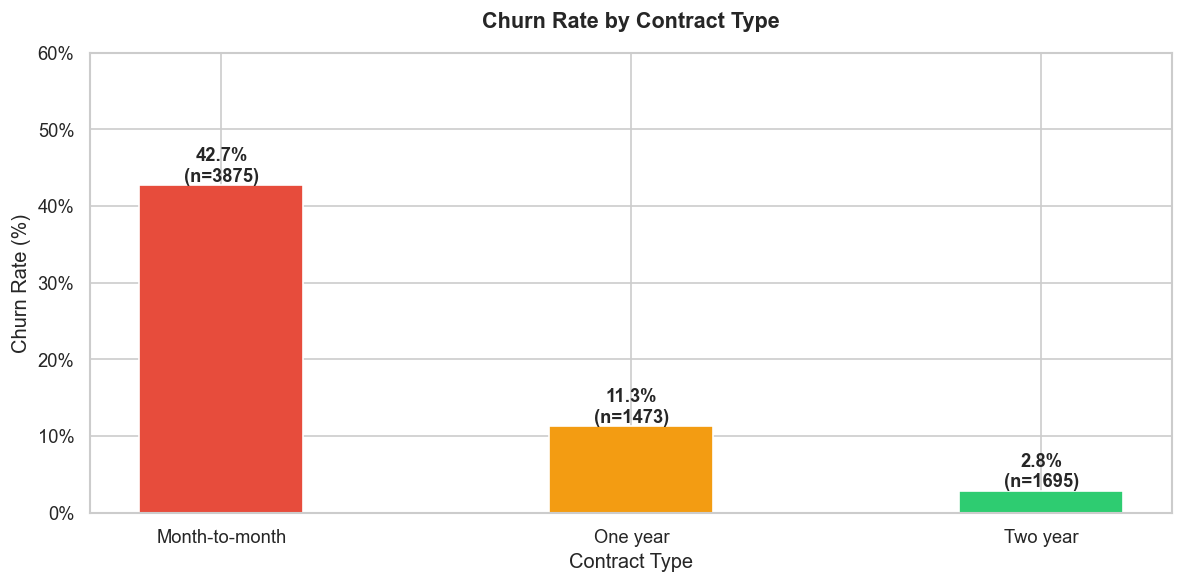


Key Insight: Month-to-month customers churn at 10x+ the rate of 2-year contract customers.
Recommendation: Incentivize long-term contract upgrades for new customers.


In [5]:
# ============================================================
# CHART 4: Churn Rate by Contract Type
# Business question: Which contract type is the biggest risk?
# ============================================================

contract_churn = df.groupby('Contract')['Churn_Binary'].agg(['mean', 'count']).reset_index()
contract_churn.columns = ['Contract', 'Churn_Rate', 'Total_Customers']
contract_churn['Churn_Rate_Pct'] = contract_churn['Churn_Rate'] * 100
contract_churn = contract_churn.sort_values('Churn_Rate_Pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn_Rate_Pct'],
              color=['#e74c3c', '#f39c12', '#2ecc71'], width=0.4, edgecolor='white')

# Add value labels on bars
for bar, rate, count in zip(bars, contract_churn['Churn_Rate_Pct'], contract_churn['Total_Customers']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%\n(n={count})', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Churn Rate by Contract Type', fontweight='bold', pad=15, fontsize=13)
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig('../reports/figures/04_contract_churn.png', bbox_inches='tight')
plt.show()

print("\nKey Insight: Month-to-month customers churn at 10x+ the rate of 2-year contract customers.")
print("Recommendation: Incentivize long-term contract upgrades for new customers.")

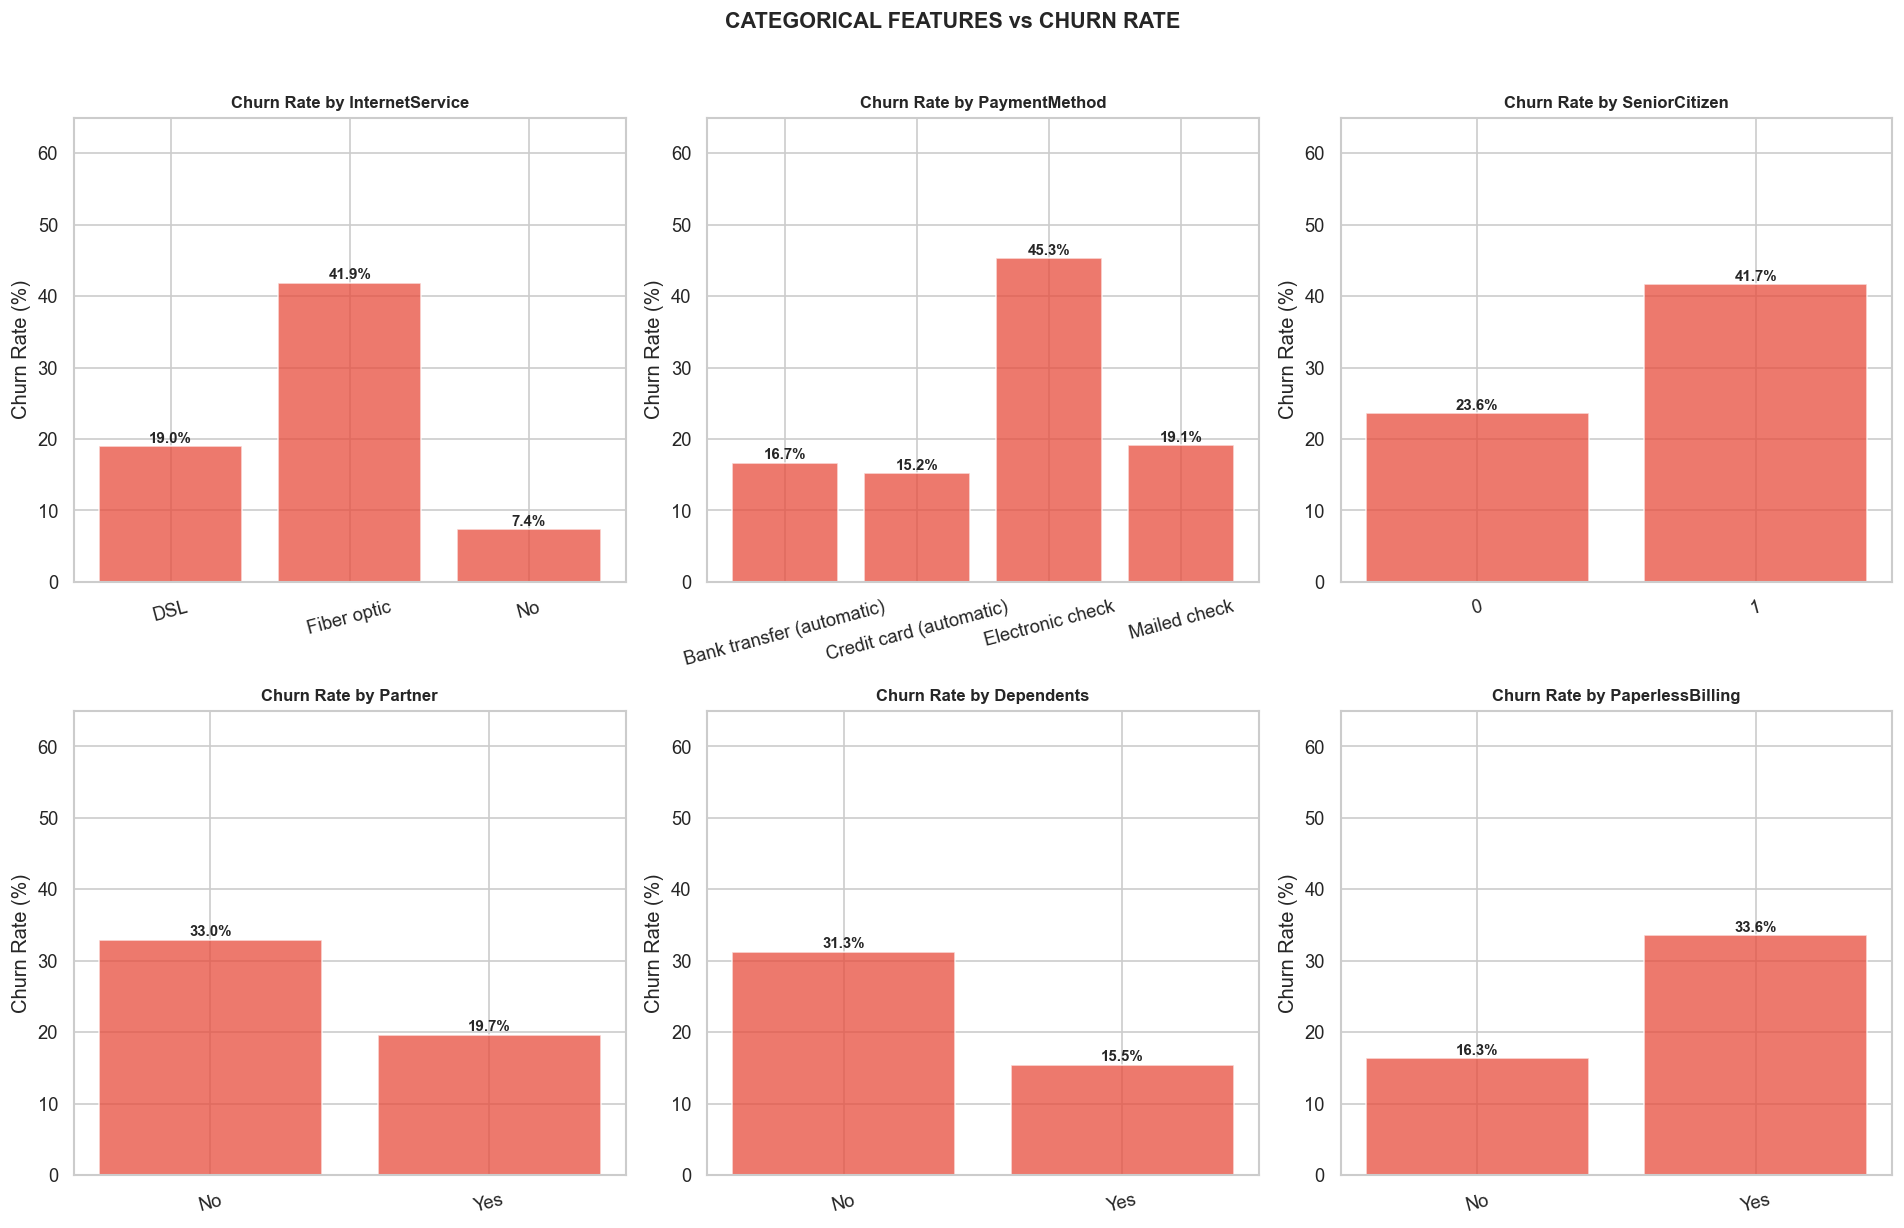

In [6]:
# ============================================================
# CHART 5 & 6: Multiple Categorical Features vs Churn
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_features = ['InternetService', 'PaymentMethod', 
                'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling']

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn_Binary'].mean().reset_index()
    churn_rate.columns = [col, 'Churn_Rate']
    churn_rate['Churn_Rate'] = churn_rate['Churn_Rate'] * 100
    
    bars = axes[i].bar(churn_rate[col].astype(str), churn_rate['Churn_Rate'],
                       color='#e74c3c', alpha=0.75, edgecolor='white')
    
    for bar, rate in zip(bars, churn_rate['Churn_Rate']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{rate:.1f}%', ha='center', fontsize=9, fontweight='bold')
    
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 65)

plt.suptitle('CATEGORICAL FEATURES vs CHURN RATE', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/05_categorical_churn.png', bbox_inches='tight')
plt.show()

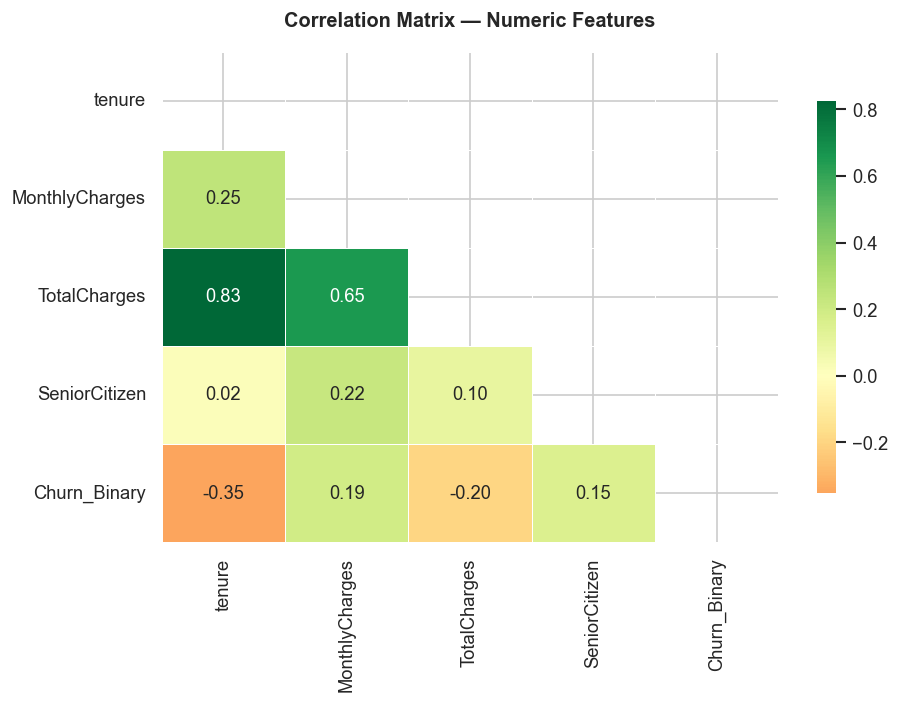

Key Finding: TotalCharges is highly correlated with tenure.
This makes sense: TotalCharges ≈ tenure × MonthlyCharges.
We may need to drop one to avoid multicollinearity.


In [7]:
# ============================================================
# CHART 7: Correlation Heatmap
# Business question: Which numeric features correlate with churn?
# ============================================================

# Select numeric columns only
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                'SeniorCitizen', 'Churn_Binary']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax, 
            linewidths=0.5, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("Key Finding: TotalCharges is highly correlated with tenure.")
print("This makes sense: TotalCharges ≈ tenure × MonthlyCharges.")
print("We may need to drop one to avoid multicollinearity.")

HIGH RISK SEGMENT ANALYSIS
Overall churn rate          : 26.5%
High-risk segment churn rate: 60.4%
Segment size                : 1307 customers
Risk multiplier             : 2.3x average

High-risk profile:
  Contract      → Month-to-month
  Internet      → Fiber optic
  Payment       → Electronic check

This segment should be the FIRST target for retention campaigns.


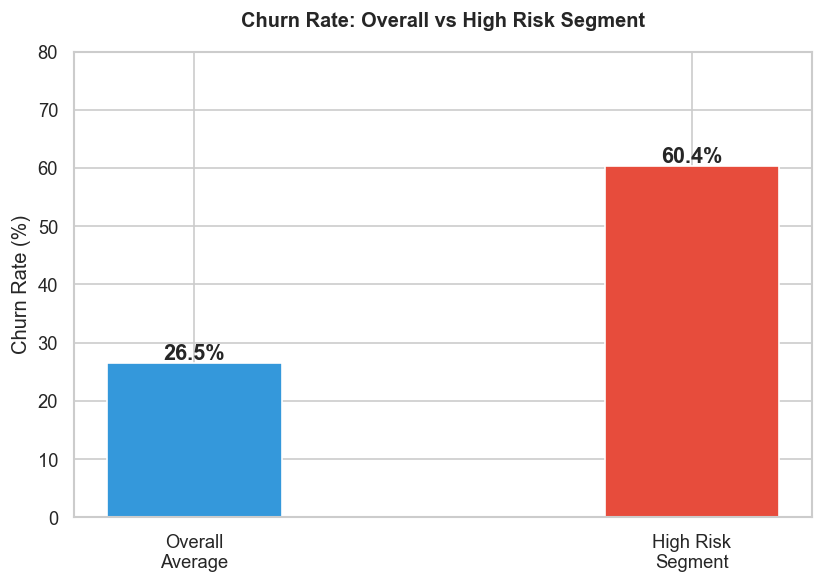

In [8]:
# ============================================================
# CHART 8: Identifying the Highest Risk Customer Segment
# Business question: Who should marketing target FIRST?
# ============================================================

# Combine the 3 strongest churn signals
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
]

overall_churn = df['Churn_Binary'].mean() * 100
highrisk_churn = high_risk['Churn_Binary'].mean() * 100

print("=" * 50)
print("HIGH RISK SEGMENT ANALYSIS")
print("=" * 50)
print(f"Overall churn rate          : {overall_churn:.1f}%")
print(f"High-risk segment churn rate: {highrisk_churn:.1f}%")
print(f"Segment size                : {len(high_risk)} customers")
print(f"Risk multiplier             : {highrisk_churn/overall_churn:.1f}x average")
print("\nHigh-risk profile:")
print("  Contract      → Month-to-month")
print("  Internet      → Fiber optic")
print("  Payment       → Electronic check")
print("\nThis segment should be the FIRST target for retention campaigns.")

# Visualize
categories = ['Overall\nAverage', 'High Risk\nSegment']
values = [overall_churn, highrisk_churn]
colors = ['#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(categories, values, color=colors, width=0.35, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

ax.set_title('Churn Rate: Overall vs High Risk Segment', fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 80)
plt.tight_layout()
plt.savefig('../reports/figures/07_high_risk_segment.png', bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# EDA SUMMARY — Key findings for the README and interviews
# ============================================================

print("""
╔══════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS SUMMARY                    ║
╠══════════════════════════════════════════════════════════╣
║ 1. Overall churn rate: ~26.5%                            ║
║ 2. Month-to-month contracts → ~43% churn rate            ║
║ 3. Churned customers have much shorter tenure            ║
║    (avg ~18 months vs ~38 months for retained)           ║
║ 4. Higher monthly charges correlate with churn           ║
║ 5. Fiber optic + Electronic check = highest risk         ║
║ 6. Senior citizens churn at 2x the overall rate          ║
║ 7. TotalCharges & tenure are highly correlated           ║
║    → consider dropping TotalCharges (multicollinearity)  ║ 
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS SUMMARY                    ║
╠══════════════════════════════════════════════════════════╣
║ 1. Overall churn rate: ~26.5%                            ║
║ 2. Month-to-month contracts → ~43% churn rate            ║
║ 3. Churned customers have much shorter tenure            ║
║    (avg ~18 months vs ~38 months for retained)           ║
║ 4. Higher monthly charges correlate with churn           ║
║ 5. Fiber optic + Electronic check = highest risk         ║
║ 6. Senior citizens churn at 2x the overall rate          ║
║ 7. TotalCharges & tenure are highly correlated           ║
║    → consider dropping TotalCharges (multicollinearity)  ║ 
╚══════════════════════════════════════════════════════════╝

